In-Lab Task 1

In [1]:
# Import necessary libraries
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

I0000 00:00:1775034237.246448   75354 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In-Lab Task 2

In [2]:
#Load and preprocess the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [ ]:
import numpy as np
# This tells numpy: "Don't wrap lines, and don't shorten the output"
np.set_printoptions(linewidth=200, threshold=1000)

print(train_images[2])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0   0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0   0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   0   0   0   0  2

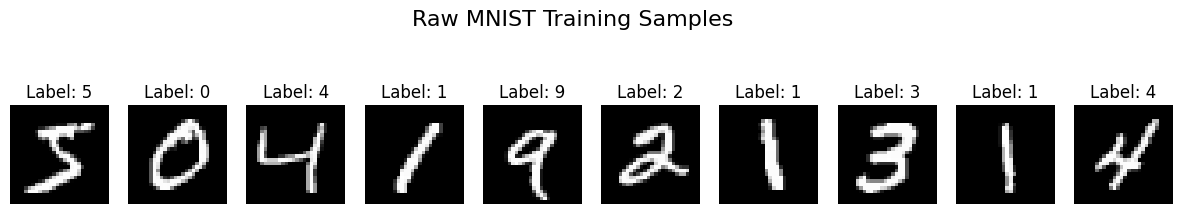

In [ ]:
import matplotlib.pyplot as plt

# Visualize the first 10 training samples immediately after loading
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    # At this stage, images are already (28, 28)
    plt.imshow(train_images[i], cmap='gray')
    # At this stage, labels are still simple integers
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

plt.suptitle("Raw MNIST Training Samples", fontsize=16)
plt.show()

In [ ]:
train_images.shape

(60000, 28, 28)

In [3]:

# Reshape and normalize the images
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

In [ ]:
train_images.shape

(60000, 28, 28, 1)

In-Lab Task 3

In [4]:
# One-hot encode the labels
train_labels = to_categorical (train_labels)
test_labels = to_categorical(test_labels)

In-Lab Task 4

In [5]:
#Build the CNN model
model = Sequential()
# Step 1: Convolutional Layer with ReLU activation
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Step 2: Max Pooling Layer
model.add(MaxPooling2D((2, 2)))
# Step 3: Convolutional Layer with ReLU activation
model.add(Conv2D(64, (3, 3), activation='relu'))
# Step 4: Max Pooling Layer
model.add(MaxPooling2D((2, 2)))
# Step 5: Flatten Layer
model.add(Flatten())
#Step 6: Dense (Fully Connected) Layer with ReLU activation
model.add(Dense (64, activation='relu'))
# Step 7: Output Layer with Softmax activation (for multi-class classification)
model.add(Dense (10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/home/muhammad-ahmad/miniconda3/envs/ncomp-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In-Lab Task 5

In [6]:
#Train the model
model.fit(train_images, train_labels, epochs=2,
batch_size=64,
validation_data=(test_images, test_labels))

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.9486 - loss: 0.1714 - val_accuracy: 0.9796 - val_loss: 0.0631
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9840 - loss: 0.0533 - val_accuracy: 0.9884 - val_loss: 0.0394


In-Lab Task 6

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test Accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0360
Test Accuracy: 0.988099992275238


In-Lab Task 7
Muhammad Ahmad | FA23-BCE-113

In [8]:
# Gradio app for handwritten digit prediction
def preprocess_for_mnist(image):
    if image is None:
        return None

    # Gradio Sketchpad can return a dict with composite/layers in newer versions
    if isinstance(image, dict):
        composite = image.get("composite")
        layers = image.get("layers") or []
        image = composite if composite is not None else (layers[-1] if layers else None)
        if image is None:
            return None

    arr = np.array(image)

    # Handle RGB/RGBA images by converting to grayscale
    if arr.ndim == 3:
        arr = arr[..., :3].mean(axis=-1)
    elif arr.ndim != 2:
        return None

    arr = arr.astype("uint8")
    pil_image = Image.fromarray(arr).convert("L").resize((28, 28), Image.Resampling.LANCZOS)
    arr = np.array(pil_image).astype("float32") / 255.0

    # MNIST digits are light on dark background
    if arr.mean() > 0.5:
        arr = 1.0 - arr

    return arr.reshape(1, 28, 28, 1)

def predict_digit(image):
    if "model" not in globals():
        return "Please run training cells first.", {}

    processed = preprocess_for_mnist(image)
    if processed is None:
        return "Please draw a digit first.", {}

    probs = model.predict(processed, verbose=0)[0]
    pred_digit = int(np.argmax(probs))
    confidence = float(np.max(probs))

    result_text = f"Predicted Digit: {pred_digit}\nConfidence: {confidence:.2%}"
    class_scores = {str(i): float(probs[i]) for i in range(10)}
    return result_text, class_scores

digit_app = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(
        type="numpy",
        image_mode="L",
        height=280,
        width=280,
        label="Draw a digit (0-9)"
    ),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(num_top_classes=3, label="Top Class Probabilities")
    ],
    title="MNIST CNN Digit Classifier",
    description="Muhammad Ahmad | FA23-BCE-113\nRun previous training cells first, then draw a digit and click Submit."
)

# Local launch only
digit_app.launch(share=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
